#📌 Extracão

In [15]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# URL da API
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

# Requisição para obter os dados
resposta = requests.get(url)

# Converter resposta para JSON
dados_json = resposta.json()

# Visualizar parte do JSON
dados_json[:2]

[{'customerID': '0002-ORFBO',
  'Churn': 'No',
  'customer': {'gender': 'Female',
   'SeniorCitizen': 0,
   'Partner': 'Yes',
   'Dependents': 'Yes',
   'tenure': 9},
  'phone': {'PhoneService': 'Yes', 'MultipleLines': 'No'},
  'internet': {'InternetService': 'DSL',
   'OnlineSecurity': 'No',
   'OnlineBackup': 'Yes',
   'DeviceProtection': 'No',
   'TechSupport': 'Yes',
   'StreamingTV': 'Yes',
   'StreamingMovies': 'No'},
  'account': {'Contract': 'One year',
   'PaperlessBilling': 'Yes',
   'PaymentMethod': 'Mailed check',
   'Charges': {'Monthly': 65.6, 'Total': '593.3'}}},
 {'customerID': '0003-MKNFE',
  'Churn': 'No',
  'customer': {'gender': 'Male',
   'SeniorCitizen': 0,
   'Partner': 'No',
   'Dependents': 'No',
   'tenure': 9},
  'phone': {'PhoneService': 'Yes', 'MultipleLines': 'Yes'},
  'internet': {'InternetService': 'DSL',
   'OnlineSecurity': 'No',
   'OnlineBackup': 'No',
   'DeviceProtection': 'No',
   'TechSupport': 'No',
   'StreamingTV': 'No',
   'StreamingMovies': 

#🔧 Transformação

In [16]:
# Transformar JSON em DataFrame
dados = pd.json_normalize(dados_json)

# Ajustar nomes das colunas (remover pontos)
dados.columns = dados.columns.str.replace('.', '_')

# Verificar estrutura dos dados
dados.info()

# Verificar valores nulos
print("Valores nulos:")
print(dados.isnull().sum())

# Verificar duplicados
print("Duplicados:")
print(dados.duplicated().sum())

# Visualizar dados
dados.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#📊 Carga e análise

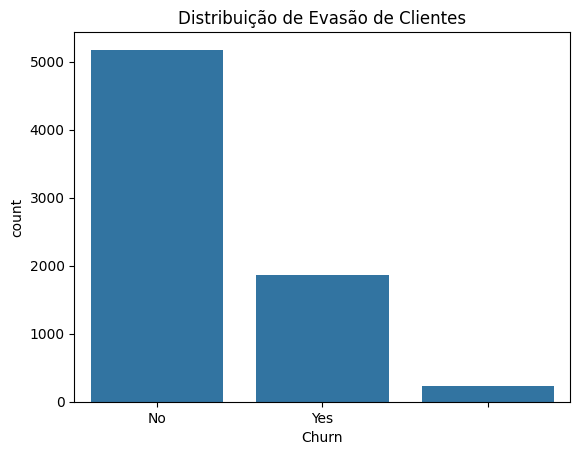

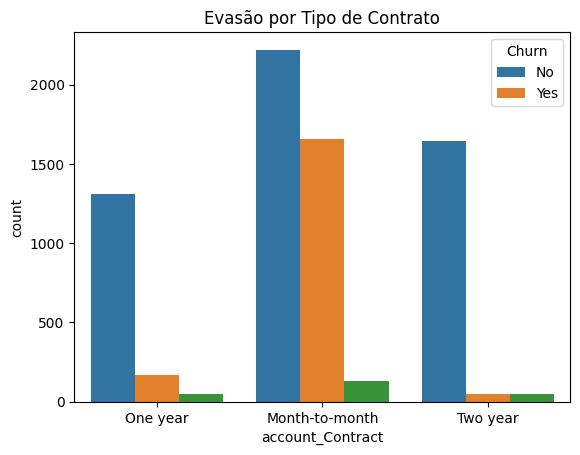

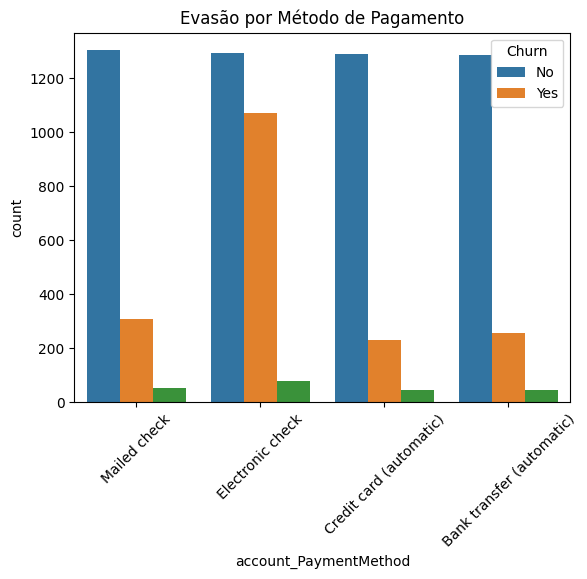

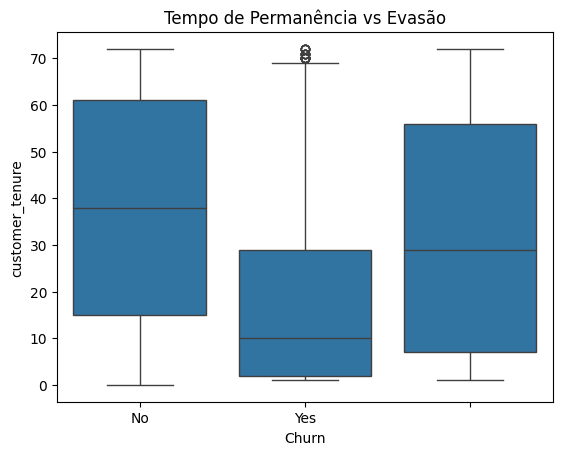

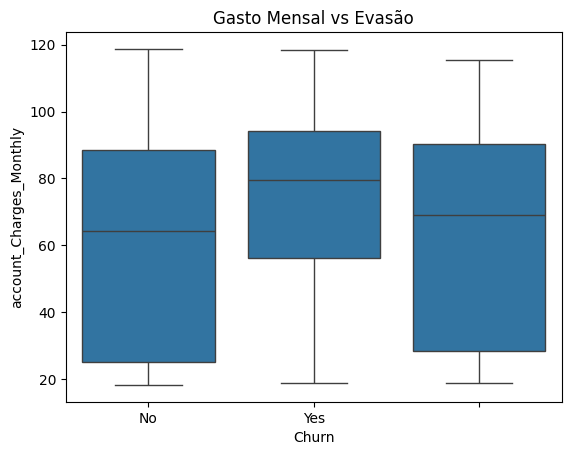

In [17]:
# Análise descritiva
dados.describe()

# Distribuição de evasão
sns.countplot(x='Churn', data=dados)

plt.title("Distribuição de Evasão de Clientes")
plt.show()


# Evasão por tipo de contrato
sns.countplot(x='account_Contract', hue='Churn', data=dados)

plt.title("Evasão por Tipo de Contrato")
plt.show()


# Evasão por método de pagamento
sns.countplot(x='account_PaymentMethod', hue='Churn', data=dados)

plt.xticks(rotation=45)
plt.title("Evasão por Método de Pagamento")
plt.show()


# Tempo de permanência vs evasão
sns.boxplot(x='Churn', y='customer_tenure', data=dados)

plt.title("Tempo de Permanência vs Evasão")
plt.show()


# Gasto mensal vs evasão
sns.boxplot(x='Churn', y='account_Charges_Monthly', data=dados)

plt.title("Gasto Mensal vs Evasão")
plt.show()

#📄Relatorio Final

## Introdução

A Telecom X enfrenta um alto índice de evasão de clientes (Churn). O objetivo desta análise foi explorar os dados disponíveis para identificar padrões que possam explicar os cancelamentos de clientes.

## Limpeza e Tratamento de Dados

Os dados foram extraídos de uma API em formato JSON e transformados em um DataFrame utilizando a biblioteca Pandas. Durante o processo de transformação, os dados foram normalizados e os nomes das colunas foram ajustados para facilitar a análise.

Também foram verificadas inconsistências como valores nulos e duplicados para garantir a qualidade dos dados.

## Análise Exploratória de Dados

Foram realizadas análises estatísticas e visualizações utilizando Matplotlib e Seaborn. Os gráficos permitiram observar a distribuição da evasão de clientes e a relação entre o churn e variáveis como tipo de contrato, método de pagamento, tempo de permanência e valores cobrados mensalmente.

## Conclusões

A análise mostrou que clientes com contratos de curto prazo e menor tempo de permanência tendem a apresentar maior probabilidade de cancelamento. Além disso, determinados métodos de pagamento também parecem estar associados a maiores taxas de evasão.

## Recomendações

A empresa pode desenvolver estratégias de retenção para clientes novos e incentivar contratos de longo prazo. Também é recomendado avaliar os métodos de pagamento e oferecer benefícios para clientes com maior tempo de permanência.